In [1]:
import warnings
warnings.filterwarnings("ignore")

import osmnx as ox
import matplotlib.pyplot as plt
import numpy as np

city_data_vault = {}

def calculate_orientation_entropy(bearings, num_bins=36):
    if not bearings:
        return 0.0
    bins = np.arange(0, 360 + 360 / num_bins, 360 / num_bins)
    counts, _ = np.histogram(bearings, bins=bins)
    prob = counts / counts.sum()
    prob = prob[prob > 0] 
    entropy = -np.sum(prob * np.log(prob))
    return entropy

def generate_styled_map(zone_id, coords, label, dist=3000):
    G = ox.graph_from_point(coords, dist=dist, network_type='drive')
    G_proj = ox.project_graph(G)
    
    fig, ax = ox.plot_graph(
        G_proj, 
        node_size=5,          
        node_color='#FF8C00', 
        edge_color='white',   
        edge_linewidth=0.6,   
        bgcolor='black',      
        show=False, 
        close=False
    )
    plt.show()
    
    G = ox.add_edge_bearings(G)
    bearings = [d['bearing'] for u, v, k, d in G.edges(keys=True, data=True) if 'bearing' in d]
    
    entropy_val = calculate_orientation_entropy(bearings)
    
    fig_rose, ax_rose = ox.plot_orientation(
        G, 
        num_bins=36, 
        figsize=(5, 5),
        color='#003366',    
        edgecolor='k',      
        linewidth=0.5
    )
    plt.show()
    
    nodes_gdf, _ = ox.graph_to_gdfs(G_proj)
    stats = ox.basic_stats(G_proj)
    try:
        area_m2 = nodes_gdf.union_all().convex_hull.area
    except AttributeError:
        area_m2 = nodes_gdf.unary_union.convex_hull.area
    
    intersections = len([d for n, d in G_proj.degree() if d > 2])
    
    city_data_vault[label] = {
        'area': area_m2 / 1_000_000,
        'nodes': stats['n'],
        'edges': stats['m'],
        'intersections': intersections,
        'avg_degree': stats['k_avg'],
        'avg_length': stats['edge_length_avg'],
        'circuity': stats.get('circuity_avg', 0),
        'bearing_std': np.std(bearings) if bearings else 0,
        'orientation_entropy': entropy_val
    }

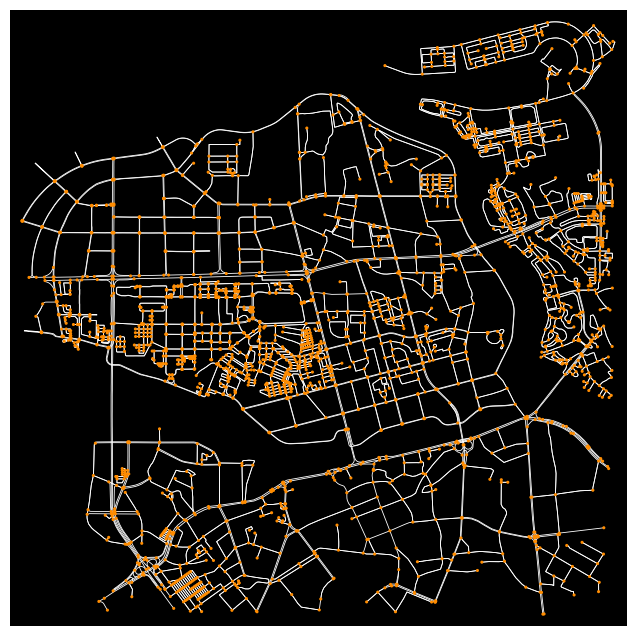

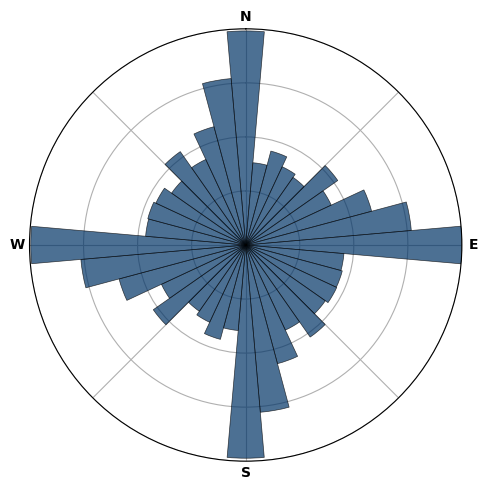

In [2]:
generate_styled_map("A", (20.060, 110.335), "Haidian Island (North)")

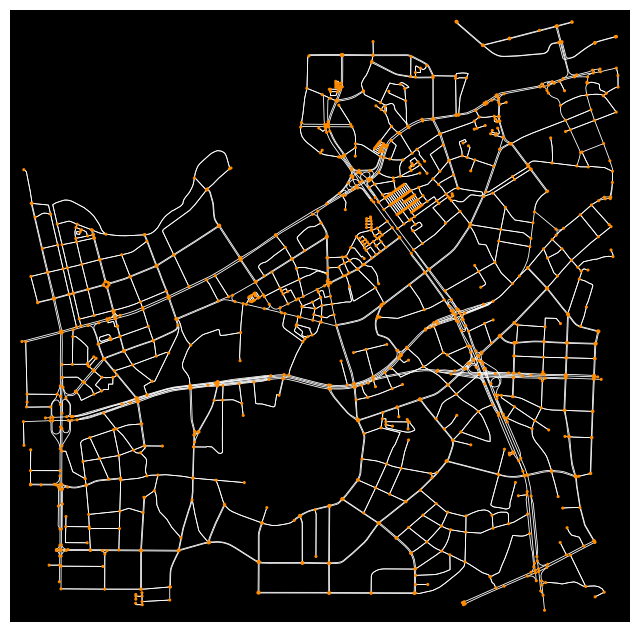

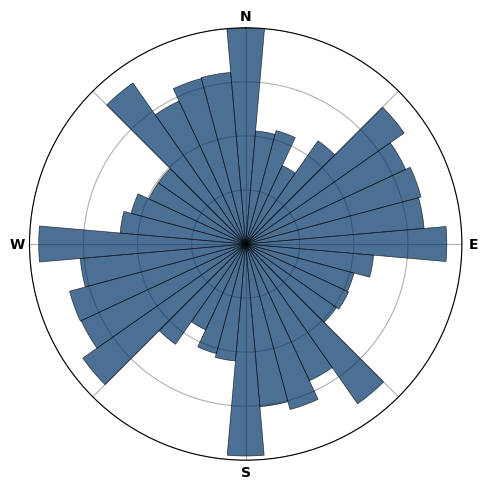

In [3]:
generate_styled_map("B", (20.025, 110.315), "City Center (North-Central)")

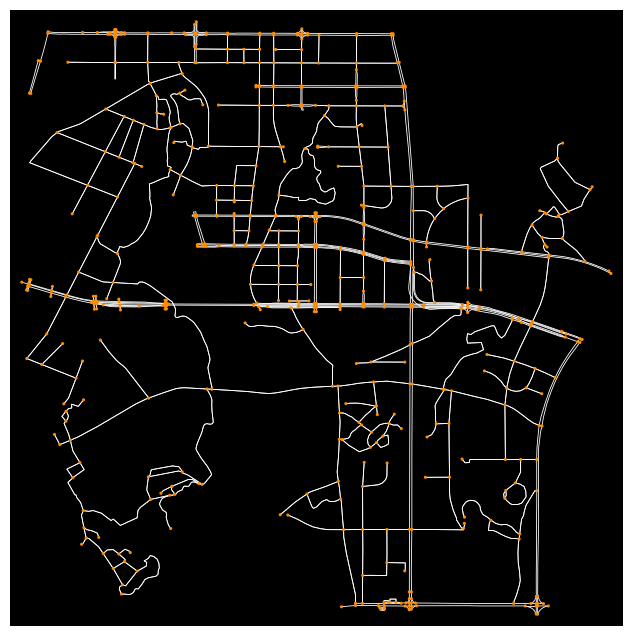

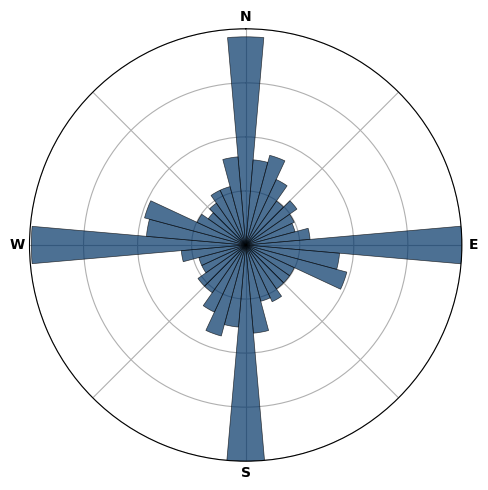

In [4]:
generate_styled_map("C", (20.020, 110.195), "West Coast (Northwest)")

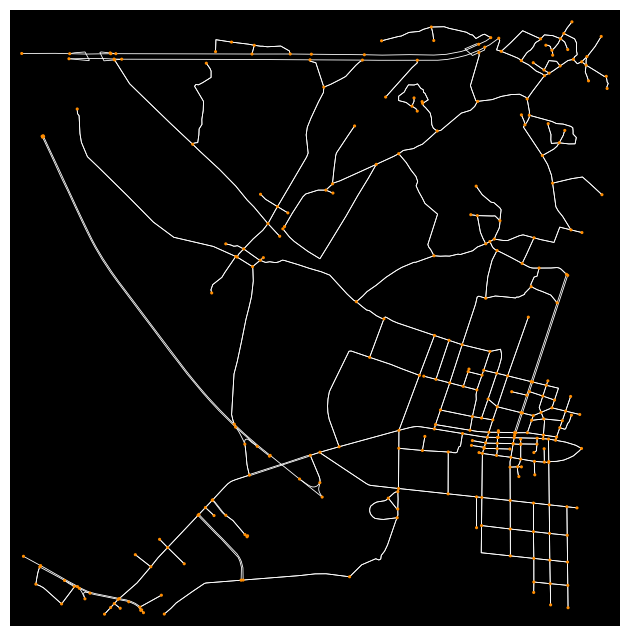

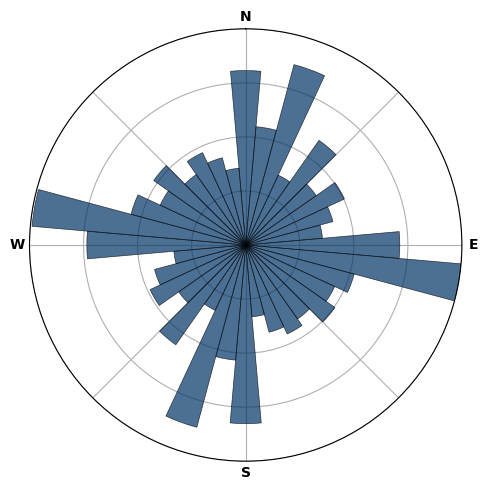

In [5]:
generate_styled_map("D", (19.995, 110.450), "Jiangdong New Area (Southeast)")

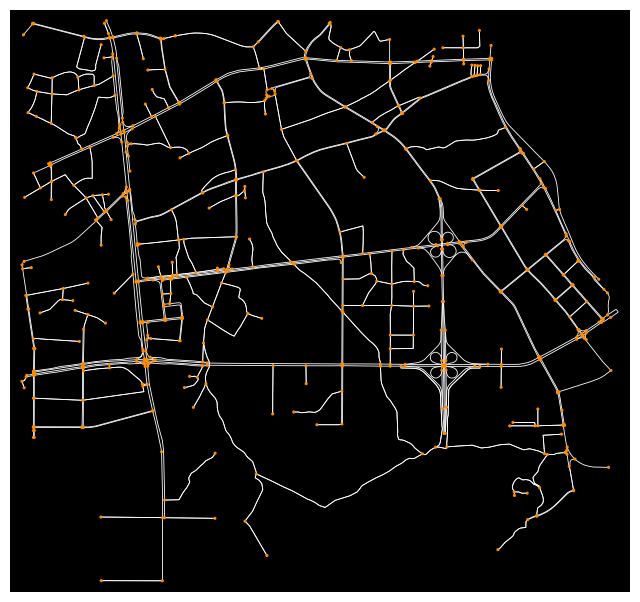

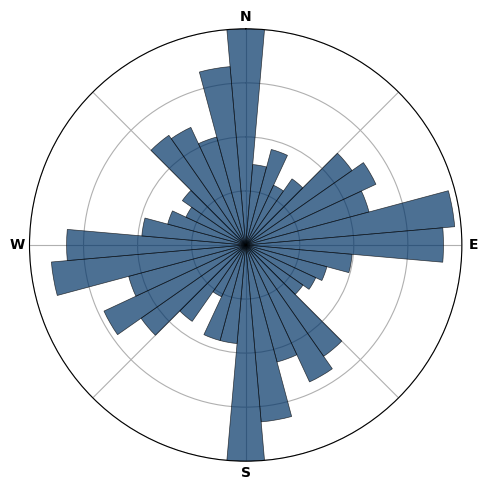

In [6]:
generate_styled_map("E", (19.985, 110.355), "Qiongshan Old Town (South)")

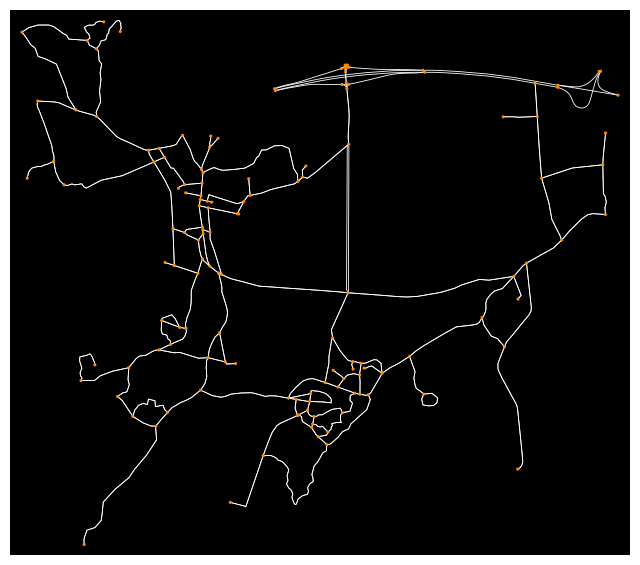

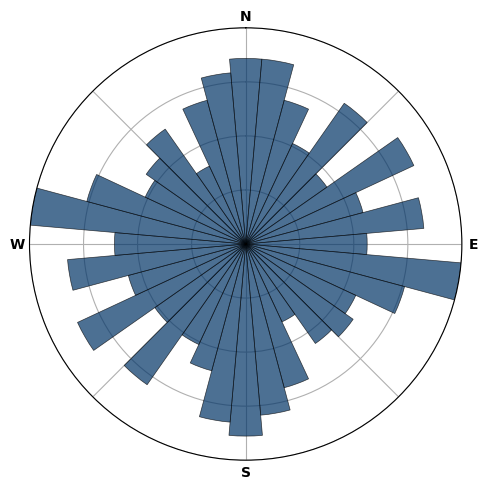

In [7]:
generate_styled_map("F", (19.935, 110.215), "Volcano Cluster (Southwest)")

In [8]:
print("\n" + "="*60)
print("HAIKOU CITY MORPHOLOGY: QUANTITATIVE SUMMARY")
print("="*60)

for label, d in city_data_vault.items():
    
    print(f"\n>> {label.upper()}")
    

    density = d['intersections'] / d['area']
    print(f"   Scale: {d['area']:.2f} sq km | {d['nodes']} nodes")
    print(f"   Connectivity: {density:.2f} nodes/km² | Degree: {d['avg_degree']:.2f}")
    print(f"   Complexity: {d['avg_length']:.1f}m avg length | {d['circuity']:.3f} circuity")
    

    if d['bearing_std'] < 30:
        morph = "GRIDIRON / REGULAR"
    elif d['bearing_std'] < 50:
        morph = "HYBRID / SEMI-REGULAR"
    else:
        morph = "ORGANIC / COMPLEX"
        
    print(f"   Bearing Std: {d['bearing_std']:.2f} ({morph})")




HAIKOU CITY MORPHOLOGY: QUANTITATIVE SUMMARY

>> HAIDIAN ISLAND (NORTH)
   Scale: 29.54 sq km | 2789 nodes
   Connectivity: 83.55 nodes/km² | Degree: 4.63
   Complexity: 90.4m avg length | 1.080 circuity
   Bearing Std: 105.01 (ORGANIC / COMPLEX)

>> CITY CENTER (NORTH-CENTRAL)
   Scale: 31.66 sq km | 1353 nodes
   Connectivity: 38.79 nodes/km² | Degree: 4.39
   Complexity: 149.4m avg length | 1.045 circuity
   Bearing Std: 104.48 (ORGANIC / COMPLEX)

>> WEST COAST (NORTHWEST)
   Scale: 30.21 sq km | 591 nodes
   Connectivity: 15.89 nodes/km² | Degree: 4.46
   Complexity: 216.1m avg length | 1.050 circuity
   Bearing Std: 106.41 (ORGANIC / COMPLEX)

>> JIANGDONG NEW AREA (SOUTHEAST)
   Scale: 32.57 sq km | 305 nodes
   Connectivity: 6.88 nodes/km² | Degree: 4.79
   Complexity: 265.9m avg length | 1.056 circuity
   Bearing Std: 104.59 (ORGANIC / COMPLEX)

>> QIONGSHAN OLD TOWN (SOUTH)
   Scale: 30.03 sq km | 622 nodes
   Connectivity: 17.41 nodes/km² | Degree: 3.78
   Complexity: 216.8

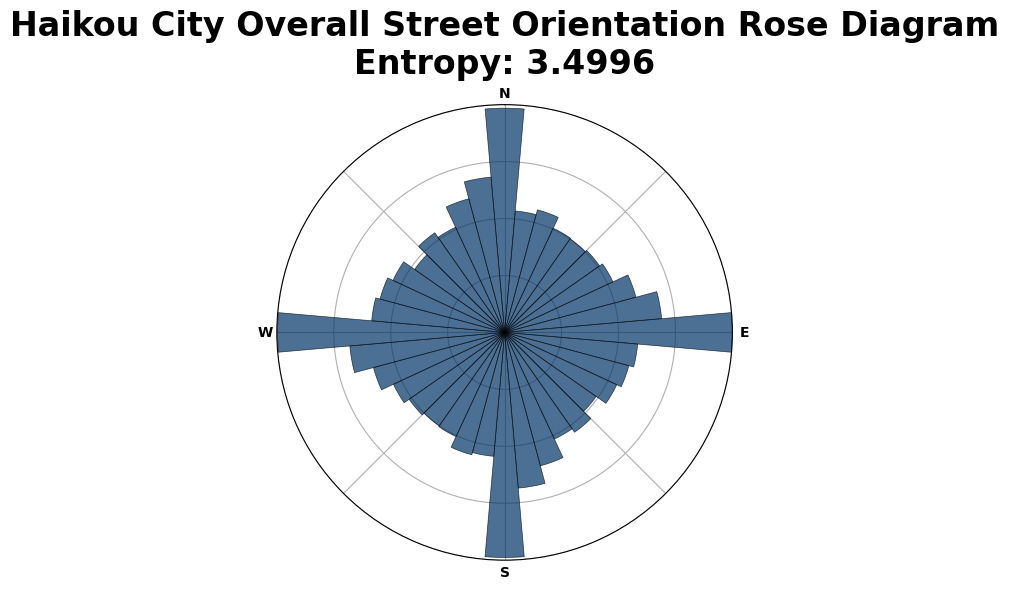

In [10]:
city_query = "Haikou, Hainan, China"

G_haikou = ox.graph_from_place(city_query, network_type='drive')
G_haikou = ox.add_edge_bearings(G_haikou)

bearings_haikou = [d['bearing'] for u, v, k, d in G_haikou.edges(keys=True, data=True) if 'bearing' in d]

haikou_entropy = calculate_orientation_entropy(bearings_haikou, num_bins=36)

fig_haikou, ax_haikou = ox.plot_orientation(
    G_haikou, 
    num_bins=36, 
    title=f"Haikou City Overall Street Orientation Rose Diagram\nEntropy: {haikou_entropy:.4f}",
    figsize=(6, 6),
    color='#003366',     
    edgecolor='black',
    linewidth=0.5
)
plt.show()